# Figure 7



In [19]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
from stable_baselines3 import PPO,SAC, DDPG
import os

def run_rl_simulation(X0, mux, model_name):

    experiment_name = model_name
    best_model_path = os.path.join('experiments', experiment_name, 'model', 'best_model.zip')

    loaded_model = SAC.load(best_model_path)

    # Initial conditions
    X0 = X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = mux   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

In [20]:
# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_simulation(start_volume, feed_gap, ramp_factor, X0, mux):

    initial_volume = start_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor 

    # Initial conditions
    X0 = X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = mux  # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_gap
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO * 1e6)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

# Figure 7a
Basic RL model adapting to unseen initial conditions

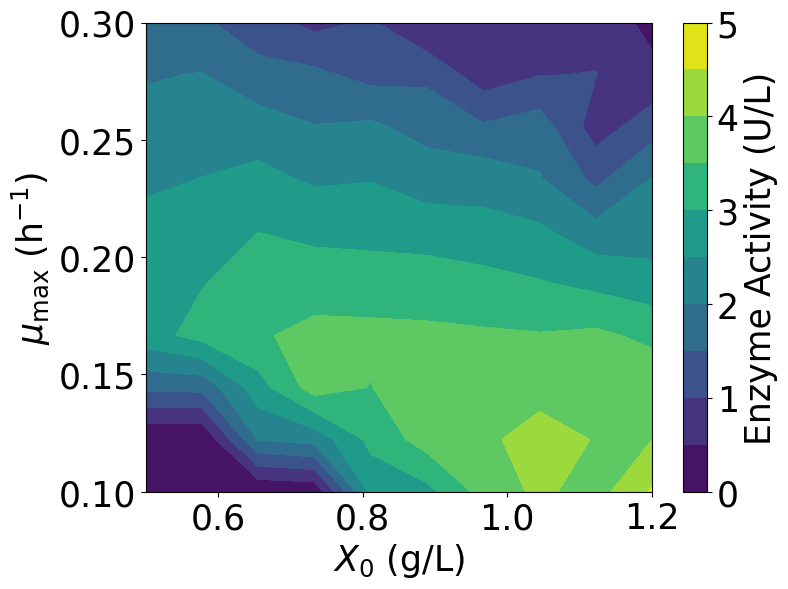

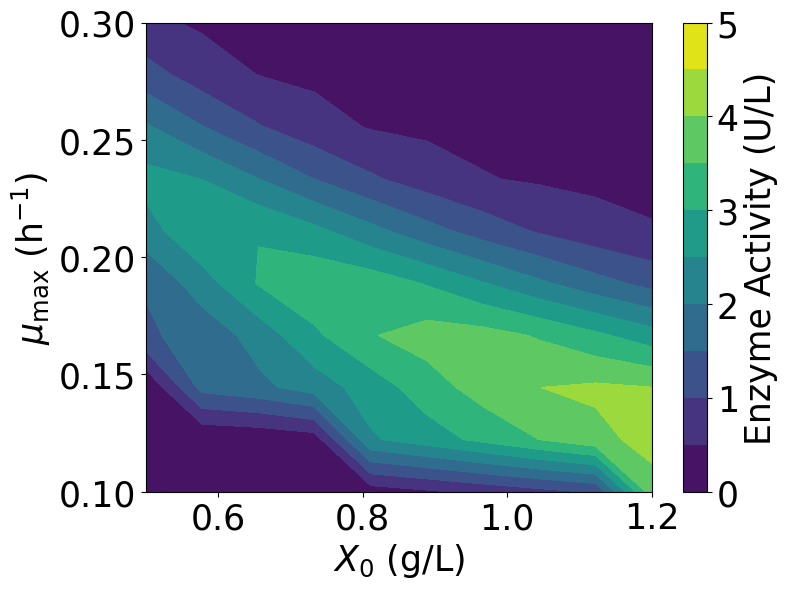

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Define the input data
initial_cell_concs = np.linspace(0.5, 1.2, 10)  # X-axis: Initial Cell Concentrations
muX_concs = np.linspace(0.1, 0.3, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(initial_cell_concs, muX_concs)

# Initialize Z for the first simulation (run_rl_simulation)
Z1 = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z1[i, j] = run_rl_simulation(
            X[i, j],  # Pass single value from X
            Y[i, j],   # Pass single value from Y
            "sac_evalcb_novar"
        )

# Initialize Z for the second simulation (run_simulation)
Z2 = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z2[i, j] = run_simulation(
            0.0008940234401919025, 
            0.1668597235239694,
            0.06416817479783203,
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Set the maximum Z-axis value to 5 for both plots
z_max = 5
z_min = min(np.min(Z1), np.min(Z2))  # Set the minimum Z value to the lower bound of both Z1 and Z2

# Define levels with a step of 0.5
levels = np.arange(z_min, z_max + 0.5, 0.5)

# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
# Create the first contour plot (from run_rl_simulation)
fig1, ax1 = plt.subplots(figsize=(8, 6))
contour1 = ax1.contourf(X, Y, Z1, levels=levels, cmap="viridis")
cbar1 = fig1.colorbar(contour1, ax=ax1)  # Add colorbar for the first plot
cbar1.set_label('Enzyme Activity (U/L)', fontsize=25)  # Set the colorbar label
cbar1.ax.tick_params(labelsize=25)
ax1.set_xlabel(r'$X_0$ (g/L)', fontsize=25)
ax1.set_ylabel(r'$\mu_{{\mathrm{max}}}$ (h$^{-1}$)', fontsize=25)
ax1.tick_params(axis='both', labelsize=25)  # Set font size for ticks
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tight_layout()
figure_path = os.path.join('figures', 'figure7', 'figure7a.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()


# Create the second contour plot (from run_simulation)
fig2, ax2 = plt.subplots(figsize=(8, 6))
contour2 = ax2.contourf(X, Y, Z2, levels=levels, cmap="viridis")
cbar2 = fig2.colorbar(contour2, ax=ax2)  # Add colorbar for the second plot
cbar2.set_label('Enzyme Activity (U/L)', fontsize=25)  # Set the colorbar label
cbar2.ax.tick_params(labelsize=25)
ax2.set_xlabel(r'$X_0$ (g/L)', fontsize=25)
ax2.set_ylabel(r'$\mu_{{\mathrm{max}}}$ (h$^{-1}$)', fontsize=25)
ax2.tick_params(axis='both', labelsize=25)  # Set font size for ticks
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tight_layout()
figure_path = os.path.join('figures', 'figure7', 'figure7b.svg')
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()


# Figure 7b

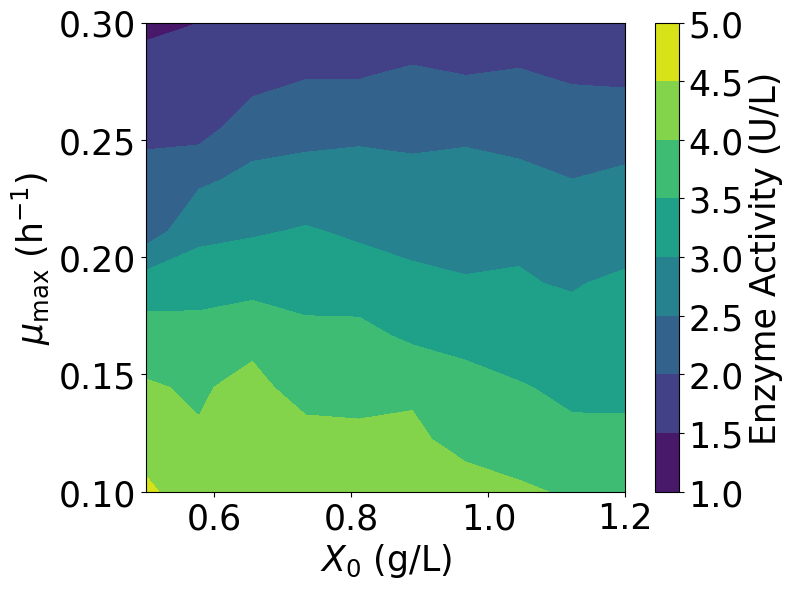

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Define the input data
initial_cell_concs = np.linspace(0.5, 1.2, 10)  # X-axis: Initial Cell Concentrations
muX_concs = np.linspace(0.1, 0.3, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(initial_cell_concs, muX_concs)

# Initialize Z for the first simulation (run_rl_simulation)
Z1 = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z1[i, j] = run_rl_simulation(
            X[i, j],  # Pass single value from X
            Y[i, j],   # Pass single value from Y
            'sac_2'
        )


# Create the first contour plot (from run_rl_simulation)
fig1, ax1 = plt.subplots(figsize=(8, 6))
contour1 = ax1.contourf(X, Y, Z1, cmap="viridis")
cbar1 = fig1.colorbar(contour1, ax=ax1)  # Add colorbar for the first plot
cbar1.set_label('Enzyme Activity (U/L)', fontsize=25)  # Set the colorbar label
cbar1.ax.tick_params(labelsize=25)
ax1.set_xlabel(r'$X_0$ (g/L)', fontsize=25)
ax1.set_ylabel(r'$\mu_{{\mathrm{max}}}$ (h$^{-1}$)', fontsize=25)
ax1.tick_params(axis='both', labelsize=25)  # Set font size for ticks
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tight_layout()
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
figure_path = os.path.join('figures', 'figure7', 'figure7c.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()


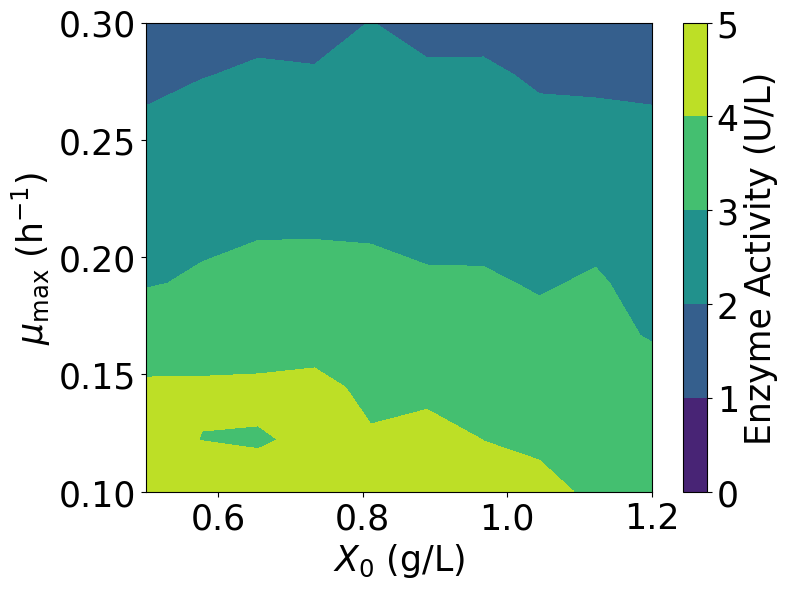

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Define the input data
initial_cell_concs = np.linspace(0.5, 1.2, 10)  # X-axis: Initial Cell Concentrations
muX_concs = np.linspace(0.1, 0.3, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(initial_cell_concs, muX_concs)

# Initialize Z for the first simulation (run_rl_simulation)
Z1 = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z1[i, j] = run_rl_simulation(
            X[i, j],  # Pass single value from X
            Y[i, j],   # Pass single value from Y
            'sac_2'
        )

# Set the Z-axis (colorbar) scale
z_min, z_max = 0, 5  # Desired Z-axis range
levels = np.arange(z_min, z_max + 1, 1)  # Levels with a gap of 1 unit

# Create the contour plot
fig1, ax1 = plt.subplots(figsize=(8, 6))
contour1 = ax1.contourf(X, Y, Z1, cmap="viridis", levels=levels, vmin=z_min, vmax=z_max)  # Scale Z-axis
cbar1 = fig1.colorbar(contour1, ax=ax1)  # Add colorbar
cbar1.set_label('Enzyme Activity (U/L)', fontsize=25)  # Set the colorbar label
cbar1.ax.tick_params(labelsize=25)  # Set font size for colorbar ticks

# Add labels and formatting
ax1.set_xlabel(r'$X_0$ (g/L)', fontsize=25)
ax1.set_ylabel(r'$\mu_{{\mathrm{max}}}$ (h$^{-1}$)', fontsize=25)
ax1.tick_params(axis='both', labelsize=25)  # Set font size for ticks
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tight_layout()
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
# Save the figure
figure_path = os.path.join('figures', 'figure7', 'figure7c.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()
